In [1]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from utils.io import read_anndata

adata = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Eraslan2022.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

dask: False, backed: False
Read slot "obs", store as "obs"...


/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


In [2]:
adata.obs["tissue"].unique()

['gastrocnemius', 'breast', 'mucosa', 'esophagus muscularis mucosa', 'anterior wall of left ventricle', 'lingula of left lung', 'prostate gland', 'skin of leg']
Categories (8, object): ['breast', 'mucosa', 'gastrocnemius', 'skin of leg', 'prostate gland', 'esophagus muscularis mucosa', 'lingula of left lung', 'anterior wall of left ventricle']

In [3]:
adata

AnnData object with n_obs × n_vars = 209126 × 32088
    obs: 'Sample ID_prep', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'n_genes', 'fpr', 'prep', 'individual', 'nGenes', 'nUMIs', 'PercentMito', 'PercentRibo', 'Age_bin', 'Sample ID', 'donor_id', 'Sample ID short', 'RIN score from PAXgene tissue Aliquot', 'RIN score from Frozen tissue Aliquot', 'Autolysis Score', 'Sample Ischemic Time (mins)', 'scrublet', 'scrublet_score', 'batch', 'n_counts', 'tissue-individual-prep', 'Broad cell type', 'Granular cell type', 'introns', 'junctions', 'exons', 'sense', 'antisense', 'intergenic', 'exon_ratio', 'intron_ratio', 'junction_ratio', 'log10_nUMIs', 'leiden', 'leiden_tissue', 'Tissue composition', 'Cell types level 2', 'Cell types level 3', 'Broad cell type numbers', 'Broad cell type (numbers)', 'channel', 'development_stage_ontology_term_id', 

In [4]:
adata.obs["cell_type"].nunique()

53

In [5]:
adata.obs["donor_id"].nunique()

16

In [6]:
adata.obs["Sample ID"].nunique()

25

In [7]:
adata.obs["batch"].nunique()

95

In [8]:
batch_size = adata.obs["donor_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 13070.38
Standard deviation: 13110.38
Minimum batch size: 40
Maximum batch size: 54561
Coefficient of variance: 1.00


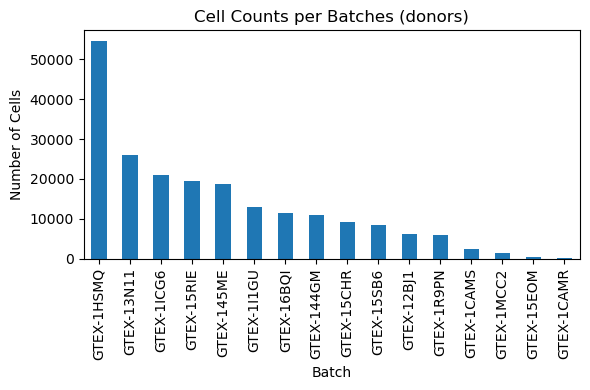

In [9]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (donors)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [1]:
adata.obs[["batch", "donor_id"]].drop_duplicates().value_counts("batch")

NameError: name 'adata' is not defined